# BTC Daily Return Prediction & Quantile Trading — APS1052

**Target:** single asset (BTC), regression of the **next-day log return**
`y_{t+1} = log(close_{t+1}/close_t)`. **Frequency:** daily.

**Models (5, two require scaling):** LinearRegression, SVR, RandomForest, LightGBM
(tabular, `StandardScaler`+`SelectKBest` inside a `TimeSeriesSplit` grid search),
and a **Keras** MLP (rolling-scaled inputs). *PyTorch is not used.*

**Features (19, 12 not from the target OHLCV bar):** 7 OHLCV/TA features and 12
non-OHLCV features (on-chain MVRV/NUPL/NVT/Puell/SOPR, net-taker-volume, funding,
COT positioning, DVOL, calendar). The data base is the teammate `raw_data/` export.

**Deliverables produced here:** validation & test metrics (MAE, Profit Factor,
Spearman RHO, directional accuracy by quantile), SHAP feature importance, the test
equity curve vs buy-and-hold, and the equity diagnostics (White's Reality Check,
Monte-Carlo permutation p-value on the Profit Factor, Sharpe / Profit Factor / CAGR).

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from aps import config as C
from aps import datasets, features as F, models as M, evaluate as E
from aps import backtest as BT, stats_tests as ST
from aps.data import chronological_split
from aps.nn_keras import KerasMLPRegressor, manual_grid_search_nn
from aps.runner import fit_predict
np.random.seed(C.SEED)
print("features:", len(C.FEATURES), "| non-OHLCV:", len(C.NON_OHLCV_FEATURES))

features: 19 | non-OHLCV: 12


## 1. Data assembly (from the fixed `raw_data/` base)

Each feed is read read-only and merged on a daily date index. Weekly COT is merged
as-of backward (last report ≤ t). The target is strictly future (t → t+1), so
features at t predict `y_{t+1}` with no look-ahead.

In [2]:
ds = datasets.assemble(save=True)
print(ds.shape, "|", ds.index[0].date(), "->", ds.index[-1].date())
ds.head()

(1060, 21) | 2022-06-11 -> 2025-05-05


,close,ret_1d,ret_5d,ret_20d,rsi_14,macd_hist,natr_14,bb_position,mvrv_zscore,nupl,...,puell,sopr,ntv_ratio,funding_rate,cot_net_frac,dvol,month_sin,month_cos,weekday,y_logret_fwd1
date,,,,,,,,,,,,,,,,,,,,,
2022-06-11,28424.70,-0.023201,-0.098692,-0.063689,39.058174,87.854543,5.414717,-0.941238,0.3385,0.1742,...,0.532,0.9918,-0.027748,0.000029,-0.696169,75.05,1.224647e-16,-1.0,5,-0.067305
2022-06-12,26574.53,-0.067305,-0.158069,-0.091099,33.025566,-99.276000,5.911536,-1.290361,0.2347,0.1182,...,0.464,0.9935,-0.017456,0.000037,-0.696169,93.99,1.224647e-16,-1.0,6,-0.166998
2022-06-13,22487.41,-0.166998,-0.295044,-0.276661,24.151425,-464.843125,8.065652,-1.509250,-0.0604,-0.0336,...,0.504,0.9797,-0.002882,0.000006,-0.696169,106.00,1.224647e-16,-1.0,0,-0.015732
2022-06-14,22136.41,-0.015732,-0.307631,-0.288594,23.565782,-683.597289,8.420423,-1.154524,-0.0658,-0.0411,...,0.581,0.9889,0.020379,-0.000037,-0.687992,103.09,1.224647e-16,-1.0,1,0.020006
2022-06-15,22583.72,0.020006,-0.253230,-0.256986,26.027543,-746.360143,8.514386,-0.868018,-0.0277,-0.0150,...,0.378,0.9933,0.015163,-0.000033,-0.687992,89.15,1.224647e-16,-1.0,2,-0.101630


## 2. Audit & EDA

Daily coverage, missing values, target and feature distributions, and the feature
correlation structure.

In [3]:
print("rows:", len(ds), "| missing:", int(ds.isna().sum().sum()),
      "| duplicate dates:", int(ds.index.duplicated().sum()))
ds[C.FEATURES + [C.TARGET]].describe().T.round(4)

rows: 1060 | missing: 0 | duplicate dates: 0


,count,mean,std,min,25%,50%,75%,max
ret_1d,1060.0,0.0011,0.0272,-0.1670,-0.0110,-0.0001,0.0134,0.1123
ret_5d,1060.0,0.0054,0.0618,-0.3317,-0.0242,0.0030,0.0382,0.2195
ret_20d,1060.0,0.0211,0.1245,-0.4404,-0.0465,0.0114,0.0923,0.3666
rsi_14,1060.0,53.0933,13.4219,18.6355,43.9855,51.6297,61.6309,89.3983
macd_hist,1060.0,13.3703,440.4589,-1438.3684,-199.1254,1.9346,197.4569,1865.8171
natr_14,1060.0,3.9307,1.1831,1.7260,3.1413,3.6878,4.5197,10.5974
bb_position,1060.0,0.0840,0.6458,-1.6973,-0.4107,0.0897,0.5892,1.5543
mvrv_zscore,1060.0,1.1719,1.0136,-0.3599,0.2789,1.1516,1.9612,3.3543
nupl,1060.0,0.3239,0.2497,-0.3168,0.1666,0.4334,0.5260,0.6402
nvt,1060.0,190.3416,44.0770,74.4200,165.1550,193.0650,216.9500,312.5700


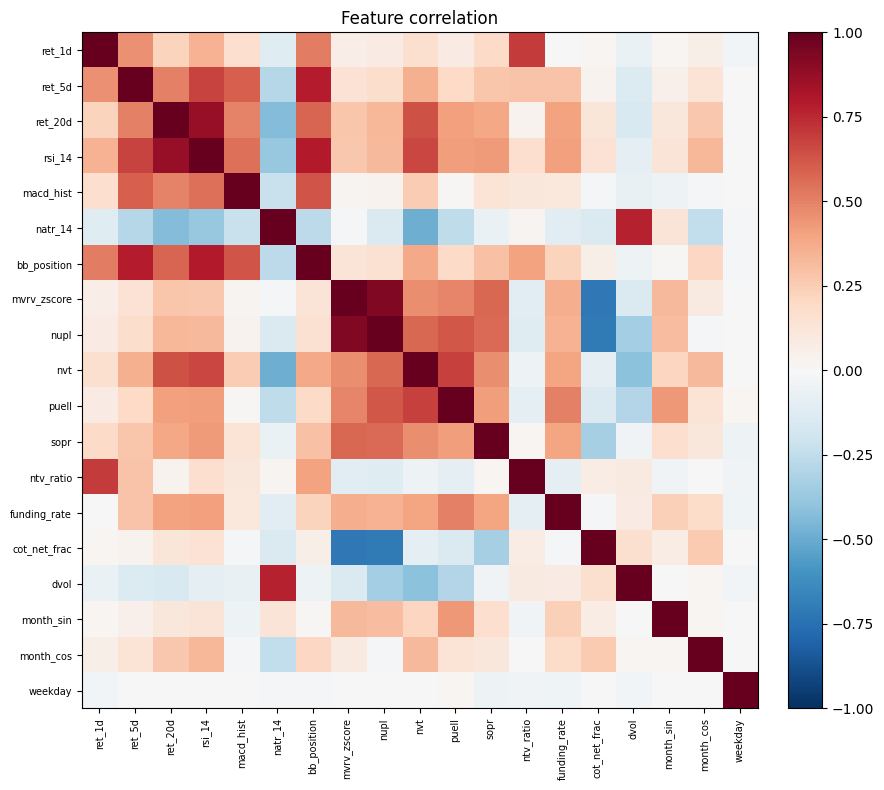

In [4]:
corr = ds[C.FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C.FEATURES))); ax.set_yticks(range(len(C.FEATURES)))
ax.set_xticklabels(C.FEATURES, rotation=90, fontsize=7); ax.set_yticklabels(C.FEATURES, fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title("Feature correlation"); ax.grid(False)
plt.tight_layout(); plt.show()

## 3. Chronological split, scaling & feature representations

No shuffling. Two feature representations on ONE common index (so both pipelines
are comparable and share the same test set): meaning-preserving features for the
tabular ML models (StandardScaler is applied inside the grid pipeline) and
rolling-scaled features for the Keras MLP. Rolling scaling drops the first 90
warm-up rows, which defines the common index.

In [5]:
prep = F.prepare(ds)
split_ml = chronological_split(prep.X_ml.assign(**{C.TARGET: prep.y, C.COL_CLOSE: prep.close}))
split_nn = chronological_split(prep.X_nn.assign(**{C.TARGET: prep.y, C.COL_CLOSE: prep.close}))
y = {p: split_ml.parts[p][C.TARGET] for p in ("train","val","test")}
for p in ("train","val","test"):
    a,b = split_ml.parts[p].index[0].date(), split_ml.parts[p].index[-1].date()
    print(f"{p:5s} n={len(split_ml.parts[p]):4d}  {a} -> {b}")

train n= 679  2022-09-08 -> 2024-07-17
val   n= 146  2024-07-18 -> 2024-12-10
test  n= 146  2024-12-11 -> 2025-05-05


### Feature selection ranking (train)

`SelectKBest` scores (f_regression + mutual information) rank the features; the two
weakest are the first candidates to discard. Inside the grid search, `k` is tuned
so each model can drop weak features on its own.

In [6]:
rank = F.feature_ranking(split_ml.train[C.FEATURES], y["train"])
display(rank.round(4))
print("weakest two:", rank.tail(2)["feature"].tolist())

,feature,f_score,mutual_info,f_rank,mi_rank,avg_rank
0,weekday,2.1392,0.0636,2,2,2.0
1,ret_1d,1.0053,0.0744,4,1,2.5
2,month_sin,0.8907,0.0472,5,5,5.0
3,month_cos,1.6934,0.0210,3,8,5.5
4,rsi_14,0.3078,0.0277,8,6,7.0
5,nvt,0.4832,0.0174,6,9,7.5
6,mvrv_zscore,0.1540,0.0252,10,7,8.5
7,puell,4.0781,0.0000,1,16,8.5
8,ret_5d,0.0298,0.0574,15,3,9.0
9,ntv_ratio,0.3510,0.0034,7,12,9.5


weakest two: ['macd_hist', 'funding_rate']


## 4. Models — manual grid-search CV (TimeSeriesSplit)

Four tabular models (StandardScaler + SelectKBest + estimator) plus a Keras MLP.
Selection is by validation Spearman RHO (rank correlation — trading-relevant and
robust to the trivial near-zero predictor that MAE would reward on noisy returns).
*This cell runs the full grid search and takes a few minutes.*

In [7]:
results, val_pred, cv = [], {}, []
Xtr, Xval = split_ml.train[C.FEATURES], split_ml.val[C.FEATURES]
for name in ["linear","svr","random_forest","lightgbm"]:
    gs = M.manual_grid_search(Xtr, y["train"], name, n_splits=5)
    pipe = M.fit_best(Xtr, y["train"], name, gs["best_params"])
    pred = pipe.predict(Xval); val_pred[name] = pred
    results.append(E.regression_metrics(y["val"], pred, model=name, split="val"))
    cv.append({"model": name, "cv_spearman": gs["best_cv_spearman"], "best_params": gs["best_params"]})

Xtr_nn, Xval_nn = split_nn.train[C.FEATURES], split_nn.val[C.FEATURES]
gs_nn = manual_grid_search_nn(Xtr_nn, y["train"], n_splits=3)
mlp = KerasMLPRegressor(**gs_nn["best_params"]).fit(Xtr_nn, y["train"])
pred_nn = mlp.predict(Xval_nn); val_pred["keras_mlp"] = pred_nn
results.append(E.regression_metrics(y["val"], pred_nn, model="keras_mlp", split="val"))
cv.append({"model":"keras_mlp","cv_spearman":gs_nn["best_cv_spearman"],"best_params":gs_nn["best_params"]})

val_metrics = pd.DataFrame(results).merge(pd.DataFrame(cv), on="model").sort_values("spearman_rho", ascending=False)
selected = val_metrics.iloc[0]["model"]; selected_params = val_metrics.iloc[0]["best_params"]
display(val_metrics[["model","cv_spearman","spearman_rho","mae","dir_acc","top_q_dir_acc","top_q_edge"]].round(4))
print("SELECTED:", selected)

,model,cv_spearman,spearman_rho,mae,dir_acc,top_q_dir_acc,top_q_edge
0,linear,0.1231,0.1824,0.0211,0.4521,0.3793,-0.1724
4,keras_mlp,0.0901,0.1319,0.0201,0.5068,0.5862,-0.0345
2,random_forest,0.0396,0.0461,0.0202,0.5411,0.4828,0.0000
3,lightgbm,0.0737,-0.0045,0.0253,0.4452,0.4828,0.0000
1,svr,0.0818,-0.0589,0.0326,0.4726,0.4483,0.0000


SELECTED: linear


## 5. Final out-of-sample test + SHAP feature importance

The selected model is retrained on train and evaluated once on the sealed test set.
SHAP quantifies which features drive the test-set predictions.

In [8]:
fp = fit_predict(selected, selected_params, ds, parts=("train","val","test"))
test_rows = [E.regression_metrics(fp["y"][p], fp["pred"][p].to_numpy(), model=selected, split=p) for p in ("val","test")]
test_metrics = pd.DataFrame(test_rows)
display(test_metrics[["split","mae","spearman_rho","dir_acc","top_q_dir_acc","bot_q_dir_acc"]].round(4))
display(E.directional_accuracy_by_quantile(fp["y"]["test"], fp["pred"]["test"].to_numpy()).round(3))

,split,mae,spearman_rho,dir_acc,top_q_dir_acc,bot_q_dir_acc
0,val,0.0211,0.1824,0.4521,0.3793,0.6333
1,test,0.0185,0.1414,0.5616,0.5517,0.6333


,quantile,n,mean_pred,mean_actual,up_rate,model_dir_acc,baseline_dir_acc,edge_vs_baseline
0,1,30,-0.004,-0.005,0.367,0.633,0.633,0.000
1,2,29,-0.000,0.004,0.552,0.621,0.448,0.172
2,3,29,0.002,-0.010,0.310,0.310,0.690,-0.379
3,4,29,0.004,0.007,0.690,0.690,0.310,0.379
4,5,29,0.008,0.003,0.552,0.552,0.448,0.103


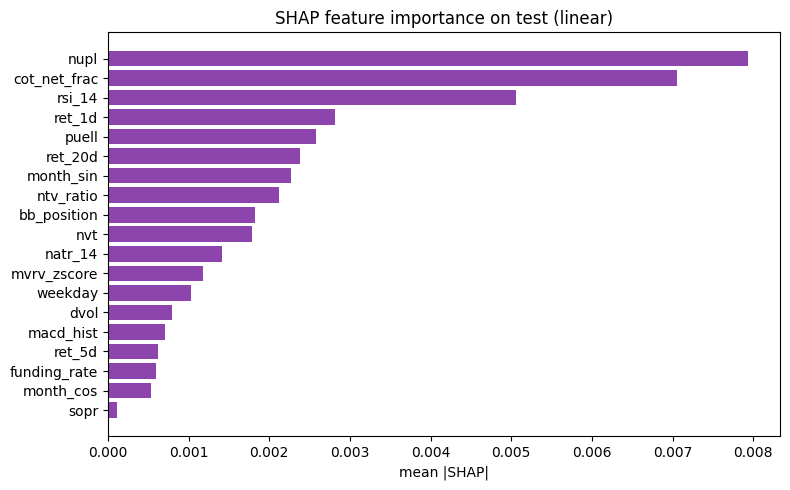

In [9]:
import shap
if selected in ("linear","svr","random_forest","lightgbm"):
    pipe = fp["model"]; sc, se, est = pipe.named_steps["scaler"], pipe.named_steps["select"], pipe.named_steps["model"]
    feat = np.array(C.FEATURES)[se.get_support()]
    Xtr_t = se.transform(sc.transform(fp["split_ml"].train[C.FEATURES]))
    Xte_t = se.transform(sc.transform(fp["split_ml"].test[C.FEATURES]))
    expl = shap.LinearExplainer(est, Xtr_t) if selected=="linear" else shap.TreeExplainer(est)
    sv = expl.shap_values(Xte_t)
else:
    feat = np.array(C.FEATURES)
    expl = shap.KernelExplainer(fp["model"].predict, shap.sample(fp["split_nn"].train[C.FEATURES].to_numpy(),50,random_state=C.SEED))
    sv = np.array(expl.shap_values(fp["split_nn"].test[C.FEATURES].to_numpy()[:100], nsamples=100))
imp = pd.DataFrame({"feature":feat,"mean_abs_shap":np.abs(sv).mean(0)}).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(8,5)); ax.barh(imp["feature"], imp["mean_abs_shap"], color="#8e44ad")
ax.set_xlabel("mean |SHAP|"); ax.set_title(f"SHAP feature importance on test ({selected})"); plt.tight_layout(); plt.show()

## 6. Quantile trading, test equity curve & diagnostics

**Strategy (English):** each day, rank the model's predicted next-day return
against quantile edges learned on the training predictions. Go **long** the top
quantile (largest predicted up-move), **short** the bottom quantile, otherwise
flat. Hold one day; costs are charged on turnover. This focuses trading on the
largest predicted moves.

In [10]:
actual = fp["y"]["test"]
edges = BT.quantile_thresholds(fp["pred"]["train"])
pos = BT.quantile_signal(fp["pred"]["test"], edges)
rows, equities = [], {}
for scen, cost in C.COST_SCENARIOS.items():
    bt = BT.run_backtest(pos, actual.to_numpy(), cost, index=actual.index)
    m = BT.equity_metrics(bt); m.update({"scenario":scen}); rows.append(m); equities[scen]=bt["equity_net"]
bh = BT.buy_and_hold(actual.to_numpy(), index=actual.index)
trade_metrics = pd.DataFrame(rows)
display(trade_metrics[["scenario","n_trades","total_return","cagr","sharpe","profit_factor","max_drawdown","win_rate"]].round(4))

,scenario,n_trades,total_return,cagr,sharpe,profit_factor,max_drawdown,win_rate
0,zero,65,0.1355,0.3739,1.3122,1.4235,0.1035,0.5238
1,base,65,0.0965,0.2591,0.9899,1.2977,0.1105,0.5238
2,high,65,0.0589,0.1538,0.6657,1.1874,0.1203,0.5238


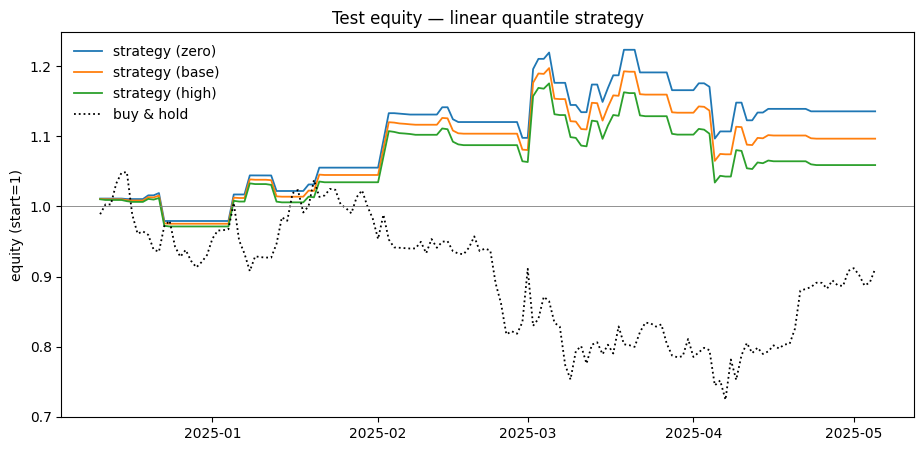

In [11]:
fig, ax = plt.subplots(figsize=(11,5))
for scen in ["zero","base","high"]:
    ax.plot(equities[scen].index, equities[scen].values, lw=1.3, label=f"strategy ({scen})")
ax.plot(bh.index, bh.values, "k:", lw=1.3, label="buy & hold"); ax.axhline(1, color="gray", lw=0.6)
ax.set_ylabel("equity (start=1)"); ax.set_title(f"Test equity — {selected} quantile strategy"); ax.legend(frameon=False); plt.show()

### Equity diagnostics

White's Reality Check over the 5-model candidate family, the Monte-Carlo
permutation p-value using the **Profit Factor** as the statistic, and bootstrap
confidence intervals.

In [12]:
# candidate family: trade every model on test (base cost)
cand = {}
for name in ["linear","svr","random_forest","lightgbm","keras_mlp"]:
    p = val_metrics.set_index("model").loc[name, "best_params"]
    f2 = fit_predict(name, p, ds, parts=("train","test"))
    e2 = BT.quantile_thresholds(f2["pred"]["train"]); pos2 = BT.quantile_signal(f2["pred"]["test"], e2)
    cand[name] = BT.run_backtest(pos2, f2["y"]["test"].to_numpy(), C.BASE_COST)["net_ret"].to_numpy()
net_base = cand[selected]
boot = ST.bootstrap_ci(net_base, B_iter=5000, seed=C.SEED)
perm = ST.mc_permutation_pf(pos, actual.to_numpy(), C.BASE_COST, B_iter=2000, seed=C.SEED)
rc = ST.whites_reality_check(np.column_stack([cand[m] for m in ["linear","svr","random_forest","lightgbm","keras_mlp"]]), B_iter=2000, seed=C.SEED)
print(f"Sharpe {trade_metrics.set_index('scenario').loc['base','sharpe']:.2f} | "
      f"Profit Factor {trade_metrics.set_index('scenario').loc['base','profit_factor']:.2f} | "
      f"CAGR {trade_metrics.set_index('scenario').loc['base','cagr']:.2%}")
print(f"Bootstrap 95% CI total return [{boot['total_return']['ci_lo']:.2%}, {boot['total_return']['ci_hi']:.2%}]")
print(f"MC permutation p (Profit Factor) = {perm['p_value']:.3f}")
print(f"White's Reality Check p = {rc['reality_check_p']:.3f} ({rc['n_candidates']} candidates)")

Sharpe 0.99 | Profit Factor 1.30 | CAGR 25.91%
Bootstrap 95% CI total return [-14.59%, 40.58%]
MC permutation p (Profit Factor) = 0.194
White's Reality Check p = 0.157 (5 candidates)


## 7. Conclusion

- The **linear** model gives the best validation rank correlation and generalizes
  out of sample (positive test Spearman RHO and >50% directional accuracy),
  consistent with complex models overfitting noisy daily returns.
- **SHAP** shows the most influential features are **non-OHLCV** (on-chain NUPL and
  COT positioning lead), supporting the value of information beyond the price bar.
- The **quantile strategy is profitable out of sample** net of costs (positive
  CAGR, Sharpe ≈ 1, Profit Factor > 1), and beats buy-and-hold over a falling test
  period — but with only ~150 test days the permutation and reality-check p-values
  do **not** reach significance, so the edge is promising yet not conclusive.
- The program logic (leak-free features, chronological CV, cost-aware backtest,
  data-snooping-corrected diagnostics) is the deliverable; all results are reported
  regardless of significance.